In [29]:
import sys; import os
sys.path.append(os.path.abspath('..'))

from python import densities, forces
import itertools, importlib
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

importlib.reload(forces);

---

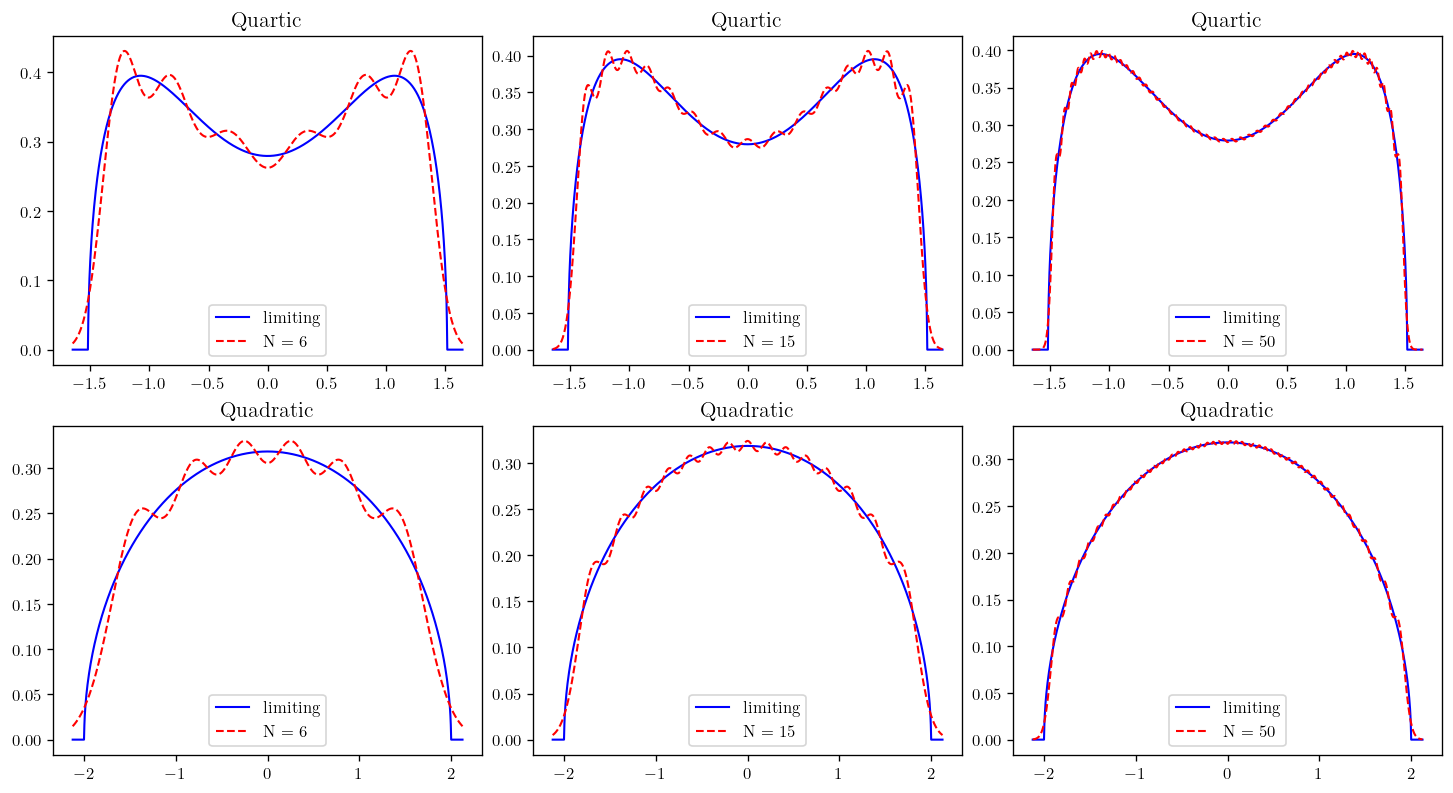

In [30]:
Ns = [6, 15, 50]
potentials = ["quartic", "quadratic"]
fig, axes2d = plt.subplots(2, 3, figsize = (12, 6.5))
axes = axes2d.flatten()

from python.forces import potential_quadratic, potential_quartic

for j, (potential_name, N) in enumerate(itertools.product(potentials, Ns)):
    s, limiting_dens = densities.get_density(potential_name)
    axes[j].plot(s, limiting_dens, label = "limiting", color = "blue")

    if (potential_name == "quartic"):
        potential_func = potential_quartic
    elif (potential_name == "quadratic"):
        potential_func = potential_quadratic

    pis, c_sqrs = densities.orthogonal_polys(N, potential_func, s)
    K_N = densities.construct_kernel(N, potential_func, s, pis, c_sqrs)
    finite_dens = np.diag(K_N)/N
    axes[j].plot(s, finite_dens, label = f"N = {N}", linestyle = "--", color = "red")
    axes[j].set_title(potential_name.capitalize())
    axes[j].legend(loc = "lower center")

plt.show()

---

If wanted, compute distance metrics from finite and limiting distributions.